# California Housing — Linear Regression with Scikit-Learn

Replicating the Coursera optional lab using a real open dataset.
Covers EDA, identifying capped values, feature engineering,
normalisation, and training with SGDRegressor.

In [560]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

## Load and Inspect Data

Load the California Housing dataset and run full EDA.
Observe df.describe() carefully for:
- Suspiciously round maximum values indicating data was capped
- MedInc is capped at 15.0001
- MedHouseVal (target) is capped at 5.0000

Capped values are unreliable training examples — the true value
exceeded the cap but we only know it hit the ceiling, not by how much.
These rows will be dropped in the next step.

In [561]:
housing_data = fetch_california_housing(as_frame=True)
df_unfiltered = housing_data.frame
print('--- Dataset overview\n')
print(f"Df shape: {df_unfiltered.shape}")
print("*" * 50)
df_unfiltered.info()
print("*" * 50)
print(df_unfiltered.describe())
print("*" * 50)
print(df_unfiltered.isnull().sum())
print("*" * 50)
print(df_unfiltered.head())

--- Dataset overview

Df shape: (20640, 9)
**************************************************
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
**************************************************
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822

## Drop Capped Values

Remove rows where MedHouseVal or MedInc are at their maximum
capped values. These rows introduce noise — the model would
learn from ceiling values rather than true prices and incomes.

After filtering, run describe() again to confirm the maximums
have dropped to more realistic values.

In [562]:
df=df_unfiltered[(df_unfiltered['MedHouseVal']<df_unfiltered['MedHouseVal'].max()) & (df_unfiltered['MedInc']<df_unfiltered['MedInc'].max())]
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  19672.000000  19672.000000  19672.000000  19672.000000  19672.000000   
mean       3.674990     28.386539      5.359523      1.096547   1441.026993   
std        1.564152     12.507507      2.288886      0.451800   1143.603621   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.526775     18.000000      4.414363      1.005894    796.000000   
50%        3.449600     28.000000      5.184171      1.048611   1179.000000   
75%        4.581425     37.000000      5.970327      1.099243   1746.000000   
max       13.147700     52.000000    132.533333     34.066667  35682.000000   

           AveOccup     Latitude     Longitude   MedHouseVal  
count  19672.000000  19672.00000  19672.000000  19672.000000  
mean       3.095196     35.65152   -119.562846      1.924625  
std       10.632782      2.14986      2.006064      0.977003  
min        0.692308     32.54000   -

## Feature Engineering

Create new features that capture relationships
more meaningfully than raw columns alone.
- Bedrms_per_room: bedroom proportion of total rooms
- People_per_room: occupancy density per room
- Total_Households: number of households in block
- City_proxim_rating: proximity to SF or LA as inverse distance

In [563]:
df['Bedrms_per_room'] = df['AveBedrms']/df['AveRooms']
df['People_per_room'] = df['AveOccup']/df['AveRooms']
df['Total_Households'] = df['Population']/df['AveOccup']

In [564]:
SF_coord = (37.7749, -122.4194)
LA_coord = (34.0522, -118.2437)

dist_to_sf = np.sqrt(((df['Latitude']-SF_coord[0])**2) + ((df['Longitude']-SF_coord[1])**2))
dist_to_la = np.sqrt(((df['Latitude']-LA_coord[0])**2) + ((df['Longitude']-LA_coord[1])**2))

closest_distance = np.minimum(dist_to_sf, dist_to_la)

df['City_proxim_rating']=1/(closest_distance + 0.1)


## Drop Redundant and Raw Columns

- Latitude and Longitude replaced by City_proxim_rating
- Population replaced by Total_Households and People_per_room
- AveRooms dropped due to high multicollinearity with Bedrms_per_room (-0.92)

In [565]:
df.drop(['Latitude', 'Longitude', 'Population', 'AveRooms'], axis=1, inplace=True)
print(df.describe())

             MedInc      HouseAge     AveBedrms      AveOccup   MedHouseVal  \
count  19672.000000  19672.000000  19672.000000  19672.000000  19672.000000   
mean       3.674990     28.386539      1.096547      3.095196      1.924625   
std        1.564152     12.507507      0.451800     10.632782      0.977003   
min        0.499900      1.000000      0.333333      0.692308      0.149990   
25%        2.526775     18.000000      1.005894      2.445502      1.166000   
50%        3.449600     28.000000      1.048611      2.837171      1.738000   
75%        4.581425     37.000000      1.099243      3.304772      2.482000   
max       13.147700     52.000000     34.066667   1243.333333      5.000000   

       Bedrms_per_room  People_per_room  Total_Households  City_proxim_rating  
count     19672.000000     19672.000000      19672.000000        19672.000000  
mean          0.215019         0.630444        501.260472            2.033805  
std           0.056976         2.964297        3

## Outlier Detection and Removal — IQR Method

Use the Interquartile Range to identify and remove statistical outliers.
Threshold: 1.5 × IQR beyond Q1 and Q3.
Applied column by column — check final df.shape to confirm
row loss is not excessive (aim to keep at least 80% of data).

In [566]:
def get_iqr_bounds(df, col, factor=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor* IQR
    upper = Q3 + factor* IQR
    return lower, upper

features = [c for c in df.select_dtypes(include='float64').columns if c!='MedHouseVal']
bounds = {}

for col in features:
    lower, upper = get_iqr_bounds(df, col)
    bounds[col] = (lower, upper)
    outliers = ((df[col]<lower)|(df[col]>upper)).sum()
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, Outliers={outliers}")

mask = pd.Series(True, index=df.index)
for col, (lower, upper) in bounds.items():
    mask = mask & (df[col]>=lower) & (df[col]<=upper)

df = df[mask]
print(df.describe())


MedInc: lower=-0.56, upper=7.66, Outliers=362
HouseAge: lower=-10.50, upper=65.50, Outliers=0
AveBedrms: lower=0.87, upper=1.24, Outliers=1354
AveOccup: lower=1.16, upper=4.59, Outliers=662
Bedrms_per_room: lower=0.08, upper=0.34, Outliers=585
People_per_room: lower=0.11, upper=1.00, Outliers=1491
Total_Households: lower=-204.00, upper=1092.00, Outliers=1165
City_proxim_rating: lower=-2.91, upper=6.53, Outliers=572
             MedInc      HouseAge     AveBedrms      AveOccup   MedHouseVal  \
count  14992.000000  14992.000000  14992.000000  14992.000000  14992.000000   
mean       3.747226     28.988794      1.046732      2.849041      1.924527   
std        1.407888     12.038251      0.066539      0.577465      0.946441   
min        0.536000      1.000000      0.866013      1.244556      0.149990   
25%        2.675000     19.000000      1.002313      2.453693      1.176000   
50%        3.596950     29.000000      1.042828      2.813855      1.782000   
75%        4.678075     37.0

## Separate Features and Target

In [567]:
y = df['MedHouseVal']
X = df.drop(['MedHouseVal'], axis=1) 

## Normalise Features — StandardScaler

Using sklearn StandardScaler instead of manual z-score.
Equivalent result — mean=0, std=1 per feature.
Scaler stores mu and sigma internally for reuse at prediction time.

In [568]:
X_mean =X.mean(axis=0)
X_std = X.std(axis=0)

In [569]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
print(f"Peak to peak range by column in Raw X:{np.ptp(X,axis=0)}")
print(f"Peak to peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")
print(X_norm[:9,:])

Peak to peak range by column in Raw X:MedInc                   7.127200
HouseAge                51.000000
AveBedrms                0.373162
AveOccup                 3.346048
Bedrms_per_room          0.219573
People_per_room          0.749054
Total_Households      1089.000000
City_proxim_rating       6.304258
dtype: float64
Peak to peak range by column in Normalized X:[5.06250249 4.23663703 5.60838829 5.7945679  5.48532509 5.23994645
 5.05528344 4.35785223]
[[ 2.49330264  1.91157113  0.4014936  -0.08101456 -1.87578599 -1.5044666
  -1.25138693  1.07490439]
 [ 1.3466535   1.91157113  0.39567773 -0.52142777 -0.50322689 -0.8057245
  -1.05641732  1.15046763]
 [ 0.07030223  1.91157113  0.51623904 -1.1560815  -0.81206471 -1.44038902
  -0.87073198  1.15046763]
 [ 0.20568681  1.91157113  0.85508889 -1.22807236  0.67879329 -0.72590012
  -1.17711279  1.15046763]
 [-0.06259627  1.91157113 -1.43335752 -1.24797329 -0.29235535 -0.85072183
   0.31301208  1.18337053]
 [-0.44552296  1.91157113  0.2268144

## Train with SGDRegressor

Stochastic Gradient Descent Regressor from sklearn.
Uses mini-batches instead of full batch gradient descent —
faster on large datasets but noisier convergence.

In [570]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm, y)
print(sgdr.get_params())
print(f"No. of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

{'alpha': 0.0001, 'average': False, 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.01, 'fit_intercept': True, 'l1_ratio': 0.15, 'learning_rate': 'invscaling', 'loss': 'squared_error', 'max_iter': 1000, 'n_iter_no_change': 5, 'penalty': 'l2', 'power_t': 0.25, 'random_state': None, 'shuffle': True, 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
No. of iterations completed: 7, number of weight updates: 104945.0


## Extract Learned Parameters

SGDRegressor stores weights in .coef_ and bias in .intercept_
Equivalent to w and b from our manual implementation.

In [571]:
w_norm = sgdr.coef_
b_norm = sgdr.intercept_
print(f"Model parameters:\nw={w_norm}, b={b_norm}")

Model parameters:
w=[ 0.73540993  0.07862347  0.05248923 -0.22034631  0.15587064  0.00463043
  0.02489413  0.22487415], b=[1.93105367]


## Verify Predictions

Confirm that manual np.dot prediction matches sgdr.predict() exactly.
Both should produce identical results since they use the same w and b.

In [572]:
# make a prediction using sgdr.predict()
y_pred_sgd = sgdr.predict(X_norm)
# make a prediction using w,b.
y_pred = np.dot(X_norm, w_norm) + b_norm
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred_sgd==y_pred).all()}")

print(f"Prediction on training set:\n{y_pred_sgd[:4]}")
print(f"Target values:\n{y[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[3.86509263 3.35759657 2.51867192 2.87994626]
Target values:
2    3.521
3    3.413
4    3.422
5    2.697
Name: MedHouseVal, dtype: float64


## Evaluate Model — Mean Squared Error

MSE measures average squared difference between predictions and targets.
Lower is better. Compare against baseline MSE of predicting the mean
to understand how much the model improves over a naive guess.

In [573]:
final_cost = mean_squared_error(y, y_pred_sgd)
print(final_cost)

0.3484038186406288


## Visualise Predictions vs Targets per Feature

Each subplot shows one feature against house price.
Orange dots are model predictions, blue are actual targets.
Features where orange and blue cluster together indicate
the model learned that feature's relationship well.

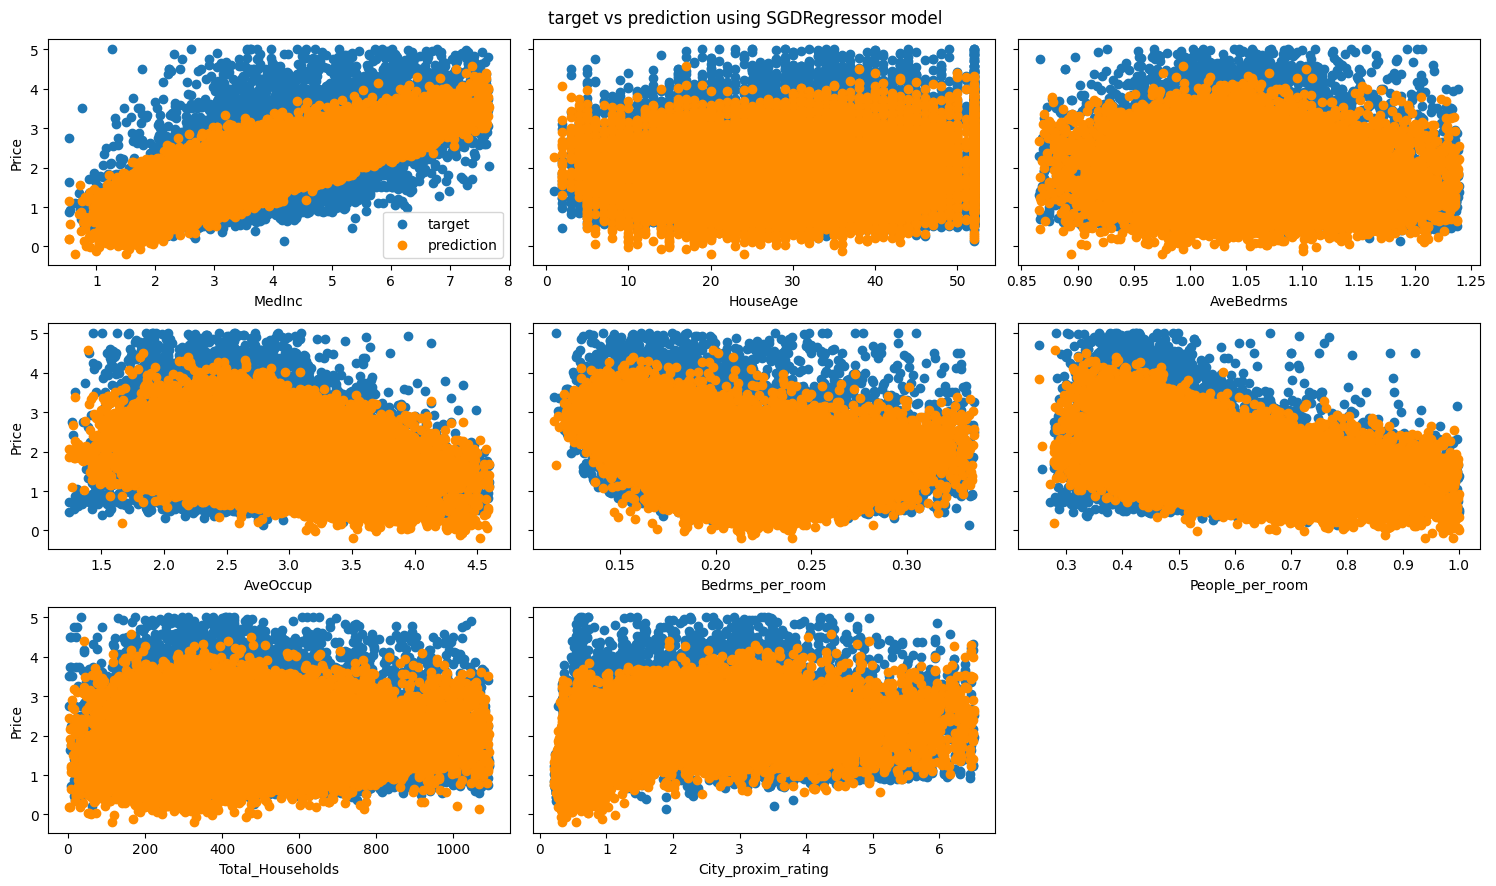

In [ ]:
n_features = X.shape[1]
n_columns = 3
n_rows = math.ceil(n_features/n_columns)

fig, ax = plt.subplots(n_rows, n_columns, figsize=(15, n_rows*3), sharey=True)
ax = ax.flatten()

for i in range(n_features):
    ax[i].scatter(X.values[:,i], y, label='target' )
    ax[i].set_xlabel(X.columns[i])
    ax[i].scatter(X.values[:,i], y_pred_sgd, c='darkorange', label='prediction')
    
    #print y label for first plot of each row
    if i%n_columns ==0:
        ax[i].set_ylabel('Price')

ax[0].legend()

#delete unused plots
for j in range(n_features, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle("target vs prediction using SGDRegressor model")
plt.tight_layout()
plt.show()

## Predict on New Data

Apply the trained model to a new unseen example.
The new input must be scaled using the same scaler fitted on training data —
not a new scaler, not manual normalisation.
scaler.transform() applies the stored mu and sigma from training.

In [575]:
new_value = np.array([[7,52,1,4,0.3,0.9,1105,6]]) 

# CRITICAL: Scale the new value using the SAME scaler before predicting
new_value_scaled = scaler.transform(new_value)
prediction = sgdr.predict(new_value_scaled)
print(prediction)

[4.40976364]


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
